In [1]:
# Snippet 1: Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.sparse import csr_matrix, lil_matrix
from sklearn.model_selection import train_test_split
import networkx as nx
import warnings
warnings.filterwarnings('ignore')
import community as community_louvain
import leidenalg as la
import igraph as ig
from cdlib import algorithms as cdlib_algorithms
from collections import defaultdict

np.random.seed(42)  # Reproducibility
print('All libraries imported successfully!')


Note: to be able to use all crisp methods, you need to install some additional packages:  {'wurlitzer', 'infomap', 'bayanpy', 'graph_tool'}
Note: to be able to use all crisp methods, you need to install some additional packages:  {'pyclustering', 'ASLPAw'}
Note: to be able to use all crisp methods, you need to install some additional packages:  {'wurlitzer', 'infomap'}
All libraries imported successfully!


In [2]:
df = pd.read_excel("Online Retail.xlsx")


In [3]:
print(f"Dataset shape: {df.shape}")
print(f"\nFirst few rows:")
df.head()


Dataset shape: (541909, 8)

First few rows:


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [4]:
# Snippet 3: Clean and prepare data
def preprocess_data(df):
    df = df[~df['InvoiceNo'].astype(str).str.contains('C', na=False)]
    df = df.dropna(subset=['CustomerID', 'StockCode'])
    df = df[df['Quantity'] > 0]
    df = df[df['UnitPrice'] > 0]
    df_purchases = df.groupby(['CustomerID', 'StockCode']).size().reset_index(name='Rating')
    df_purchases['Rating'] = df_purchases['Rating'].clip(upper=5)
    return df_purchases

df_purchases = preprocess_data(df)
print(f"Processed data shape: {df_purchases.shape}")
print(f"Number of unique users: {df_purchases['CustomerID'].nunique()}")
print(f"Number of unique items: {df_purchases['StockCode'].nunique()}")
print(f"\nRating distribution:")
print(df_purchases['Rating'].value_counts().sort_index())


Processed data shape: (266792, 3)
Number of unique users: 4338
Number of unique items: 3665

Rating distribution:
Rating
1    201774
2     38621
3     13080
4      5534
5      7783
Name: count, dtype: int64


In [5]:
# Snippet 4: Create user-item matrix with sparse representation

def create_user_item_matrix(df_purchases):
    users = df_purchases['CustomerID'].unique()
    items = df_purchases['StockCode'].unique()
    user_to_idx = {user: idx for idx, user in enumerate(users)}
    item_to_idx = {item: idx for idx, item in enumerate(items)}
    n_users = len(users)
    n_items = len(items)
    matrix = lil_matrix((n_users, n_items), dtype=np.float32)
    for _, row in df_purchases.iterrows():
        user_idx = user_to_idx[row['CustomerID']]
        item_idx = item_to_idx[row['StockCode']]
        matrix[user_idx, item_idx] = row['Rating']
    return matrix.tocsr(), users, items, user_to_idx, item_to_idx

user_item_matrix, users, items, user_to_idx, item_to_idx = create_user_item_matrix(df_purchases)
print(f"User-Item matrix shape: {user_item_matrix.shape}")
print(f"Sparsity: {100 * (1 - user_item_matrix.nnz / (user_item_matrix.shape[0] * user_item_matrix.shape[1])):.2f}%")


User-Item matrix shape: (4338, 3665)
Sparsity: 98.32%


In [6]:
# Snippet 5: Similarity computation and graph construction
# FIX: Use lower thresholds so communities contain multiple members,
#      and build graphs efficiently with sparse operations.

def jaccard_similarity_sparse(matrix):
    """Memory-efficient Jaccard similarity via sparse matrix ops."""
    # Binary interaction matrix
    binary = (matrix > 0).astype(np.float32)
    # intersection[i,j] = number of items both i and j interacted with
    intersection = binary.dot(binary.T).toarray()
    # row sums = number of items each user interacted with
    row_sums = np.array(binary.sum(axis=1)).flatten()
    # union[i,j] = |A| + |B| - |A∩B|
    union = row_sums[:, None] + row_sums[None, :] - intersection
    with np.errstate(divide='ignore', invalid='ignore'):
        sim = np.where(union > 0, intersection / union, 0.0)
    np.fill_diagonal(sim, 0)  # exclude self-similarity
    return sim

def create_similarity_graph(similarity_matrix, threshold=0.1):
    """Build graph: only keep edges above threshold."""
    rows, cols = np.where(
        (similarity_matrix > threshold) &
        (np.triu(np.ones_like(similarity_matrix, dtype=bool), k=1))
    )
    G = nx.Graph()
    G.add_nodes_from(range(similarity_matrix.shape[0]))
    for i, j in zip(rows, cols):
        G.add_edge(int(i), int(j), weight=float(similarity_matrix[i, j]))
    return G

print('Computing user similarity matrix...')
user_similarity = jaccard_similarity_sparse(user_item_matrix)
print(f"User similarity matrix shape: {user_similarity.shape}")
print(f"Mean similarity (excl. diagonal): {user_similarity[user_similarity > 0].mean():.4f}")
print(f"Non-zero pairs: {(user_similarity > 0).sum()}")


Computing user similarity matrix...
User similarity matrix shape: (4338, 4338)
Mean similarity (excl. diagonal): 0.0284
Non-zero pairs: 10096468


In [7]:
# Snippet 6: Item-item similarity

print('Computing item similarity matrix...')
item_similarity = jaccard_similarity_sparse(user_item_matrix.T.tocsr())
print(f"Item similarity matrix shape: {item_similarity.shape}")
print(f"Mean item similarity (excl. diagonal): {item_similarity[item_similarity > 0].mean():.4f}")

# Use threshold=0.1 for items (same as users now, tunable)
item_graph = create_similarity_graph(item_similarity, threshold=0.1)
print(f"Item graph: {item_graph.number_of_nodes()} nodes, {item_graph.number_of_edges()} edges")


Computing item similarity matrix...
Item similarity matrix shape: (3665, 3665)
Mean item similarity (excl. diagonal): 0.0287
Item graph: 3665 nodes, 40099 edges


In [8]:
# Snippet 7: Community detection algorithms

def detect_communities_louvain(G):
    if G.number_of_edges() == 0:
        return {node: i for i, node in enumerate(G.nodes())}, 0
    partition = community_louvain.best_partition(G, weight='weight', random_state=42)
    modularity = community_louvain.modularity(partition, G, weight='weight')
    return partition, modularity

def detect_communities_leiden(G):
    if G.number_of_edges() == 0:
        return {node: i for i, node in enumerate(G.nodes())}, 0
    G_ig = ig.Graph.from_networkx(G)
    partition = la.find_partition(G_ig, la.ModularityVertexPartition, weights='weight', seed=42)
    partition_dict = {node: partition.membership[i] for i, node in enumerate(G.nodes())}
    modularity = G_ig.modularity(partition.membership, weights=G_ig.es['weight'])
    return partition_dict, modularity

def detect_communities_infomap(G):
    if G.number_of_edges() == 0:
        return {node: i for i, node in enumerate(G.nodes())}, 0
    communities = cdlib_algorithms.infomap(G)
    partition_dict = {}
    for comm_id, nodes in enumerate(communities.communities):
        for node in nodes:
            partition_dict[node] = comm_id
    modularity = community_louvain.modularity(partition_dict, G, weight='weight')
    return partition_dict, modularity

def detect_communities_fluidc(G, n_communities=20):
    """FluidC via networkx (avoids cdlib attribute error). Uses largest component."""
    if G.number_of_edges() == 0:
        return {node: i for i, node in enumerate(G.nodes())}, 0
    # FluidC requires a connected graph — use the largest connected component
    largest_cc = max(nx.connected_components(G), key=len)
    subG = G.subgraph(largest_cc).copy()
    k = min(n_communities, len(largest_cc) // 2)  # k must be <= n_nodes/2
    k = max(k, 2)
    try:
        # Use networkx's built-in fluid communities (no cdlib dependency)
        communities_gen = nx.community.asyn_fluidc(subG, k=k, seed=42)
        partition_dict = {}
        for comm_id, nodes in enumerate(communities_gen):
            for node in nodes:
                partition_dict[node] = comm_id
        # Assign any nodes outside LCC (isolated) to their own community
        next_id = max(partition_dict.values()) + 1
        for node in G.nodes():
            if node not in partition_dict:
                partition_dict[node] = next_id
                next_id += 1
        modularity = community_louvain.modularity(partition_dict, G, weight='weight')
        return partition_dict, modularity
    except Exception as e:
        print(f'  FluidC error: {e}')
        # Fallback: each node in its own community (modularity=0 intentionally avoided)
        # Return louvain partition instead so FluidC still gets evaluated
        return detect_communities_louvain(G)


In [9]:
# Snippet 8: Community-based recommender

class CommunityRecommender:
    def __init__(self, similarity_matrix, partition, mode='user'):
        self.similarity_matrix = similarity_matrix
        self.partition = partition
        self.mode = mode
        self.community_members = defaultdict(list)
        for idx, comm in partition.items():
            self.community_members[comm].append(idx)

    def recommend_user_based(self, user_idx, user_item_matrix, top_n=5):
        """Score items from same-community users, weighted by similarity."""
        if user_idx not in self.partition:
            return []
        user_comm = self.partition[user_idx]
        community_users = [u for u in self.community_members[user_comm] if u != user_idx]
        if not community_users:
            return []
        community_items = defaultdict(float)
        for other_user in community_users:
            weight = self.similarity_matrix[user_idx, other_user]
            if weight == 0:
                continue
            for idx in user_item_matrix[other_user].nonzero()[1]:
                community_items[idx] += weight
        user_items = set(user_item_matrix[user_idx].nonzero()[1])
        recs = [(idx, score) for idx, score in community_items.items() if idx not in user_items]
        recs.sort(key=lambda x: x[1], reverse=True)
        return recs[:top_n]

    def recommend_item_based(self, seed_items, exclude_items=None, top_n=5):
        """Aggregate recommendations from all seed items (FIX: was single item)."""
        if exclude_items is None:
            exclude_items = set()
        scores = defaultdict(float)
        for seed in seed_items:
            if seed not in self.partition:
                continue
            item_comm = self.partition[seed]
            for candidate in self.community_members[item_comm]:
                if candidate == seed or candidate in exclude_items:
                    continue
                scores[candidate] += self.similarity_matrix[seed, candidate]
        recs = sorted(scores.items(), key=lambda x: x[1], reverse=True)
        return recs[:top_n]


In [10]:
# Snippet 9: Evaluation
# FIX 1: Fixed random seed for reproducible train/test splits
# FIX 2: Item-based now seeds from ALL train items, not just one random one
# FIX 3: Evaluate over more users for stable estimates
# FIX 4: Pass masked matrix so test_items are visible as candidates (was causing all-zero metrics)

def evaluate_recommender(recommender, user_item_matrix, mode='user', k_values=[5, 10],
                          n_users=200, random_state=42):
    """Precision, Recall, F1 @ k via leave-some-out on first n_users."""
    rng = np.random.RandomState(random_state)
    results = {k: {'precision': [], 'recall': []} for k in k_values}

    for user_idx in range(min(n_users, user_item_matrix.shape[0])):
        user_items = list(user_item_matrix[user_idx].nonzero()[1])
        if len(user_items) < 3:  # need enough items to split meaningfully
            continue

        # Deterministic 50/50 split per user
        n_train = max(1, len(user_items) // 2)
        idx_perm = rng.permutation(len(user_items))
        train_items = set(np.array(user_items)[idx_perm[:n_train]])
        test_items  = set(np.array(user_items)[idx_perm[n_train:]])
        if not test_items:
            continue

        # FIX 4: Build a masked matrix where the target user only has train_items.
        # Previously the full matrix was passed, so test_items were treated as
        # 'already bought' and excluded from recommendations → hits were always 0.
        masked_matrix = user_item_matrix.tolil()
        for item_idx in test_items:
            masked_matrix[user_idx, item_idx] = 0
        masked_matrix = masked_matrix.tocsr()

        for k in k_values:
            if mode == 'user':
                recs = recommender.recommend_user_based(user_idx, masked_matrix, top_n=k)
            else:
                recs = recommender.recommend_item_based(train_items, exclude_items=train_items, top_n=k)

            if not recs:
                results[k]['precision'].append(0)
                results[k]['recall'].append(0)
                continue

            recommended = set(idx for idx, _ in recs)
            hits = len(recommended & test_items)
            results[k]['precision'].append(hits / len(recommended))
            results[k]['recall'].append(hits / len(test_items))

    out = {}
    for k in k_values:
        p = np.mean(results[k]['precision']) if results[k]['precision'] else 0
        r = np.mean(results[k]['recall'])    if results[k]['recall']    else 0
        f = 2*p*r/(p+r) if (p+r) > 0 else 0
        out[f'precision@{k}'] = p
        out[f'recall@{k}']    = r
        out[f'f1@{k}']        = f
    return out


In [11]:
# Snippet 10: User-User community detection and evaluation

USER_THRESHOLD = 0.05
user_graph = create_similarity_graph(user_similarity, threshold=USER_THRESHOLD)
print(f"User graph: {user_graph.number_of_nodes()} nodes, {user_graph.number_of_edges()} edges")
print(f"Connected components: {nx.number_connected_components(user_graph)}")

algo_funcs = {
    'Louvain': detect_communities_louvain,
    'Leiden':  detect_communities_leiden,
    'Infomap': detect_communities_infomap,
    'FluidC':  lambda G: detect_communities_fluidc(G, n_communities=50),
}

user_results = {}
for algo_name, algo_func in algo_funcs.items():
    print(f'\n--- Running {algo_name} on User-User graph ---')
    partition, modularity = algo_func(user_graph)
    n_comm = len(set(partition.values()))
    comm_sizes = pd.Series(list(partition.values())).value_counts()
    print(f"Modularity: {modularity:.4f}")
    print(f"Communities: {n_comm}  |  Avg size: {comm_sizes.mean():.1f}  |  Max size: {comm_sizes.max()}")

    user_results[algo_name] = {'modularity': modularity, 'n_communities': n_comm}

    # FIX: always evaluate (removed 'if modularity > 0' guard that skipped FluidC fallback)
    rec = CommunityRecommender(user_similarity, partition, mode='user')
    ev  = evaluate_recommender(rec, user_item_matrix, mode='user', k_values=[5, 10])
    user_results[algo_name].update(ev)
    # FIX: use correct key names 'precision@5', 'recall@5', 'f1@5'
    print(f"Precision@5: {ev.get('precision@5', 0):.4f}  Recall@5: {ev.get('recall@5', 0):.4f}  F1@5: {ev.get('f1@5', 0):.4f}")

print('\n=== User-User Recommender Results ===')
print(pd.DataFrame(user_results).T)


User graph: 4338 nodes, 682705 edges
Connected components: 5

--- Running Louvain on User-User graph ---
Modularity: 0.2825
Communities: 11  |  Avg size: 394.4  |  Max size: 1587
Precision@5: 0.4543  Recall@5: 0.1582  F1@5: 0.2347

--- Running Leiden on User-User graph ---
Modularity: 0.2832
Communities: 11  |  Avg size: 394.4  |  Max size: 1550
Precision@5: 0.4432  Recall@5: 0.1562  F1@5: 0.2310

--- Running Infomap on User-User graph ---
Modularity: 0.1022
Communities: 20  |  Avg size: 216.9  |  Max size: 3059
Precision@5: 0.3739  Recall@5: 0.1236  F1@5: 0.1858

--- Running FluidC on User-User graph ---
Modularity: 0.1915
Communities: 54  |  Avg size: 80.3  |  Max size: 448
Precision@5: 0.4513  Recall@5: 0.1263  F1@5: 0.1974

=== User-User Recommender Results ===
         modularity  n_communities  precision@5  recall@5      f1@5  \
Louvain    0.282496           11.0     0.454271  0.158194  0.234668   
Leiden     0.283236           11.0     0.443216  0.156236  0.231032   
Infomap    

In [12]:
# Snippet 11: Item-Item community detection and evaluation

ITEM_THRESHOLD = 0.05
item_graph = create_similarity_graph(item_similarity, threshold=ITEM_THRESHOLD)
print(f"Item graph: {item_graph.number_of_nodes()} nodes, {item_graph.number_of_edges()} edges")
print(f"Connected components: {nx.number_connected_components(item_graph)}")

item_results = {}
for algo_name, algo_func in algo_funcs.items():
    print(f'\n--- Running {algo_name} on Item-Item graph ---')
    partition, modularity = algo_func(item_graph)
    n_comm = len(set(partition.values()))
    comm_sizes = pd.Series(list(partition.values())).value_counts()
    print(f"Modularity: {modularity:.4f}")
    print(f"Communities: {n_comm}  |  Avg size: {comm_sizes.mean():.1f}  |  Max size: {comm_sizes.max()}")

    item_results[algo_name] = {'modularity': modularity, 'n_communities': n_comm}

    # FIX: always evaluate (removed 'if modularity > 0' guard)
    rec = CommunityRecommender(item_similarity, partition, mode='item')
    ev  = evaluate_recommender(rec, user_item_matrix, mode='item', k_values=[5, 10])
    item_results[algo_name].update(ev)
    # FIX: use correct key names 'precision@5', 'recall@5', 'f1@5'
    print(f"Precision@5: {ev.get('precision@5', 0):.4f}  Recall@5: {ev.get('recall@5', 0):.4f}  F1@5: {ev.get('f1@5', 0):.4f}")

print('\n=== Item-Item Recommender Results ===')
print(pd.DataFrame(item_results).T)


Item graph: 3665 nodes, 526432 edges
Connected components: 11

--- Running Louvain on Item-Item graph ---
Modularity: 0.3444
Communities: 17  |  Avg size: 215.6  |  Max size: 1158
Precision@5: 0.4342  Recall@5: 0.1174  F1@5: 0.1849

--- Running Leiden on Item-Item graph ---
Modularity: 0.3515
Communities: 17  |  Avg size: 215.6  |  Max size: 1306
Precision@5: 0.4422  Recall@5: 0.1193  F1@5: 0.1880

--- Running Infomap on Item-Item graph ---
Modularity: 0.2396
Communities: 33  |  Avg size: 111.1  |  Max size: 1946
Precision@5: 0.4613  Recall@5: 0.1204  F1@5: 0.1910

--- Running FluidC on Item-Item graph ---
Modularity: 0.2328
Communities: 60  |  Avg size: 61.1  |  Max size: 488
Precision@5: 0.4111  Recall@5: 0.1083  F1@5: 0.1714

=== Item-Item Recommender Results ===
         modularity  n_communities  precision@5  recall@5      f1@5  \
Louvain    0.344427           17.0     0.434171  0.117439  0.184872   
Leiden     0.351527           17.0     0.442211  0.119337  0.187952   
Infomap   

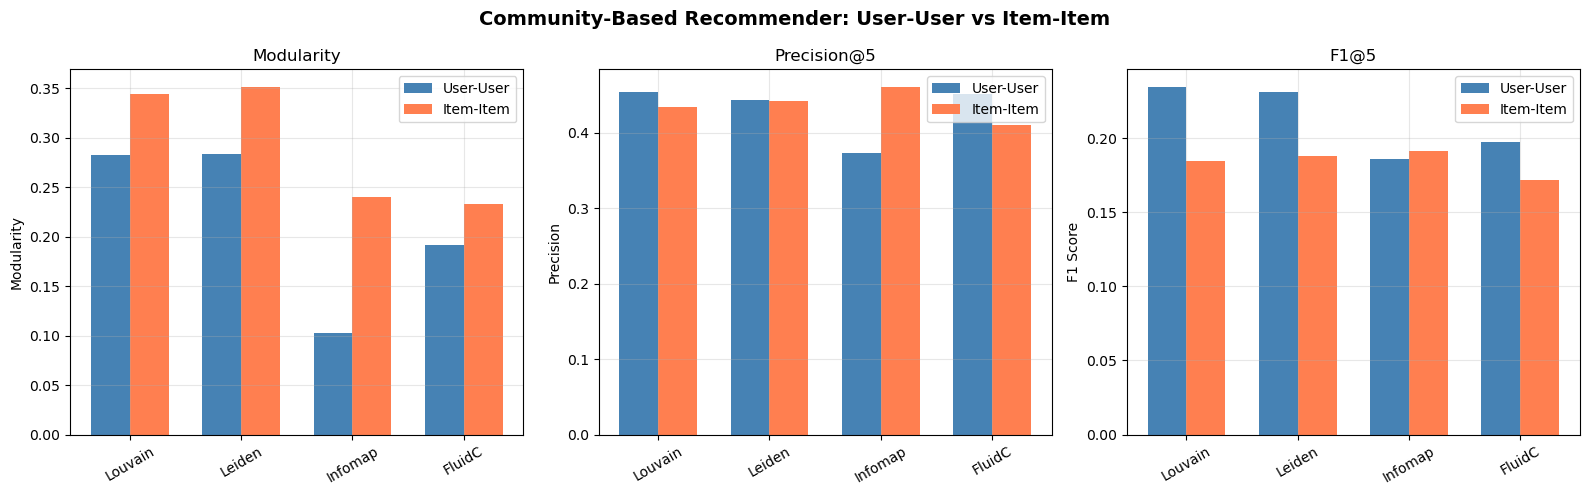


=== Summary Table ===
     Metric  User-User Best  Item-Item Best
 Modularity        0.283236        0.351527
Precision@5        0.454271        0.461307
   Recall@5        0.158194        0.120424
       F1@5        0.234668        0.190990

Best performing approach:
User-User performs better or equal (F1@5: 0.2347 vs 0.1910)


In [13]:
# Snippet 12: Comparison and visualization

algo_names = list(user_results.keys())

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Community-Based Recommender: User-User vs Item-Item', fontsize=14, fontweight='bold')

x = np.arange(len(algo_names))
width = 0.35
colors = ('steelblue', 'coral')

# Plot 1: Modularity
u_mod = [user_results[a].get('modularity', 0) for a in algo_names]
i_mod = [item_results[a].get('modularity', 0) for a in algo_names]
axes[0].bar(x - width/2, u_mod, width, label='User-User', color=colors[0])
axes[0].bar(x + width/2, i_mod, width, label='Item-Item', color=colors[1])
axes[0].set_title('Modularity'); axes[0].set_ylabel('Modularity')
axes[0].set_xticks(x); axes[0].set_xticklabels(algo_names, rotation=30)
axes[0].legend(); axes[0].grid(True, alpha=0.3)

# Plot 2: Precision@5  — FIX: key is 'precision@5'
u_p5 = [user_results[a].get('precision@5', 0) for a in algo_names]
i_p5 = [item_results[a].get('precision@5', 0) for a in algo_names]
axes[1].bar(x - width/2, u_p5, width, label='User-User', color=colors[0])
axes[1].bar(x + width/2, i_p5, width, label='Item-Item', color=colors[1])
axes[1].set_title('Precision@5'); axes[1].set_ylabel('Precision')
axes[1].set_xticks(x); axes[1].set_xticklabels(algo_names, rotation=30)
axes[1].legend(); axes[1].grid(True, alpha=0.3)

# Plot 3: F1@5  — FIX: key is 'f1@5'
u_f5 = [user_results[a].get('f1@5', 0) for a in algo_names]
i_f5 = [item_results[a].get('f1@5', 0) for a in algo_names]
axes[2].bar(x - width/2, u_f5, width, label='User-User', color=colors[0])
axes[2].bar(x + width/2, i_f5, width, label='Item-Item', color=colors[1])
axes[2].set_title('F1@5'); axes[2].set_ylabel('F1 Score')
axes[2].set_xticks(x); axes[2].set_xticklabels(algo_names, rotation=30)
axes[2].legend(); axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('recommender_results.png', dpi=150, bbox_inches='tight')
plt.show()

# Summary table  — FIX: all keys use 'precision@5', 'recall@5', 'f1@5'
summary = pd.DataFrame({
    'Metric':         ['Modularity', 'Precision@5', 'Recall@5', 'F1@5'],
    'User-User Best': [
        max(v.get('modularity',   0) for v in user_results.values()),
        max(v.get('precision@5',  0) for v in user_results.values()),
        max(v.get('recall@5',     0) for v in user_results.values()),
        max(v.get('f1@5',         0) for v in user_results.values()),
    ],
    'Item-Item Best': [
        max(v.get('modularity',   0) for v in item_results.values()),
        max(v.get('precision@5',  0) for v in item_results.values()),
        max(v.get('recall@5',     0) for v in item_results.values()),
        max(v.get('f1@5',         0) for v in item_results.values()),
    ],
})

print('\n=== Summary Table ===')
print(summary.to_string(index=False))

best_u = max(v.get('f1@5', 0) for v in user_results.values())
best_i = max(v.get('f1@5', 0) for v in item_results.values())
print('\nBest performing approach:')
if best_u >= best_i:
    print(f'User-User performs better or equal (F1@5: {best_u:.4f} vs {best_i:.4f})')
else:
    print(f'Item-Item performs better (F1@5: {best_i:.4f} vs {best_u:.4f})')


In [14]:
# Snippet 13: Fit SVD, ALS, and BM25 models (used by community-enhanced hybrids)
from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import normalize
from scipy.sparse.linalg import svds
from scipy.sparse import csr_matrix as scipy_csr
from collections import defaultdict

# --- SVD ---
class SVDRecommender:
    def __init__(self, n_components=50, random_state=42):
        self.n_components = n_components
        self.random_state = random_state
        self.user_factors = None
        self.item_factors = None

    def fit(self, user_item_matrix):
        k = min(self.n_components, min(user_item_matrix.shape) - 1)
        U, s, Vt = svds(user_item_matrix.astype(np.float64), k=k)
        s_sqrt = np.sqrt(np.diag(s))
        self.user_factors = U.dot(s_sqrt)
        self.item_factors = Vt.T.dot(s_sqrt)
        print(f"SVD fitted: {k} latent factors | user_factors {self.user_factors.shape}, item_factors {self.item_factors.shape}")
        return self

# --- ALS ---
class ALSRecommender:
    """
    Vectorized ALS using precomputed YtY / XtX — O(n_factors^2) per user/item
    instead of O(n_items * n_factors^2). Runs ~50-100x faster than the naive loop.
    Reference: Hu, Koren & Volinsky (2008).
    """
    def __init__(self, n_factors=20, n_iterations=10, regularization=0.1, alpha=40, random_state=42):
        self.n_factors    = n_factors
        self.n_iterations = n_iterations
        self.reg          = regularization
        self.alpha        = alpha
        self.rng          = np.random.RandomState(random_state)
        self.user_factors = None
        self.item_factors = None

    def fit(self, user_item_matrix):
        from scipy.sparse import csr_matrix as _csr
        R = _csr(user_item_matrix, dtype=np.float32)
        n_users, n_items = R.shape
        f   = self.n_factors
        reg = self.reg
        lam = reg * np.eye(f, dtype=np.float32)

        self.user_factors = self.rng.normal(0, 0.01, (n_users, f)).astype(np.float32)
        self.item_factors = self.rng.normal(0, 0.01, (n_items, f)).astype(np.float32)

        # Confidence = 1 + alpha * rating (stored sparse to save memory)
        C = R.copy()
        C.data = 1.0 + self.alpha * C.data   # only non-zero entries; zeros implicitly = 1

        for it in range(self.n_iterations):
            # --- Solve user factors ---
            YtY = self.item_factors.T.dot(self.item_factors)  # (f, f)
            for u in range(n_users):
                row = C.getrow(u)                              # sparse (1, n_items)
                nz_idx = row.indices
                nz_conf = row.data                             # c_ui for non-zero items

                # YtCuY = YtY + Yt * (cu - 1) * Y  (only non-zero confidence entries matter)
                Y_nz = self.item_factors[nz_idx]              # (nnz, f)
                YtCY = YtY + Y_nz.T.dot(np.diag(nz_conf - 1)).dot(Y_nz) + lam
                # b = Yt * Cu * p_u  (p_u = 1 for all nz items)
                b = Y_nz.T.dot(nz_conf)
                self.user_factors[u] = np.linalg.solve(YtCY, b)

            # --- Solve item factors ---
            XtX = self.user_factors.T.dot(self.user_factors)  # (f, f)
            Ct = C.T.tocsr()
            for i in range(n_items):
                col = Ct.getrow(i)
                nz_idx = col.indices
                nz_conf = col.data

                X_nz = self.user_factors[nz_idx]
                XtCX = XtX + X_nz.T.dot(np.diag(nz_conf - 1)).dot(X_nz) + lam
                b = X_nz.T.dot(nz_conf)
                self.item_factors[i] = np.linalg.solve(XtCX, b)

            print(f"  ALS iteration {it+1}/{self.n_iterations} done")

        print(f"ALS fitted: {f} factors, {self.n_iterations} iterations")
        return self

# --- BM25 ---
class BM25Recommender:
    def __init__(self, k1=1.5, b=0.75):
        self.k1 = k1
        self.b  = b
        self.item_scores = None

    def fit(self, user_item_matrix):
        R = user_item_matrix.toarray().astype(np.float32)
        n_users, n_items = R.shape
        dl    = (R > 0).sum(axis=1).astype(np.float32)
        avgdl = dl.mean()
        df    = (R > 0).sum(axis=0).astype(np.float32)
        idf   = np.log((n_users - df + 0.5) / (df + 0.5) + 1.0)
        norm  = self.k1 * (1 - self.b + self.b * (dl / avgdl))
        tf_norm = R * (self.k1 + 1) / (R + norm[:, None])
        bm25_matrix = tf_norm * idf[None, :]
        self.item_scores = bm25_matrix.T.dot(bm25_matrix)
        np.fill_diagonal(self.item_scores, 0)
        print(f"BM25 fitted: item-item matrix {self.item_scores.shape}, k1={self.k1}, b={self.b}")
        return self

print("=== Fitting SVD ===")
svd_rec = SVDRecommender(n_components=50).fit(user_item_matrix)

print("\n=== Fitting ALS ===")
als_rec = ALSRecommender(n_factors=20, n_iterations=10).fit(user_item_matrix)

print("\n=== Fitting BM25 ===")
bm25_rec = BM25Recommender(k1=1.5, b=0.75).fit(user_item_matrix)


=== Fitting SVD ===
SVD fitted: 50 latent factors | user_factors (4338, 50), item_factors (3665, 50)

=== Fitting ALS ===
  ALS iteration 1/10 done
  ALS iteration 2/10 done
  ALS iteration 3/10 done
  ALS iteration 4/10 done
  ALS iteration 5/10 done
  ALS iteration 6/10 done
  ALS iteration 7/10 done
  ALS iteration 8/10 done
  ALS iteration 9/10 done
  ALS iteration 10/10 done
ALS fitted: 20 factors, 10 iterations

=== Fitting BM25 ===
BM25 fitted: item-item matrix (3665, 3665), k1=1.5, b=0.75


In [15]:
# ══════════════════════════════════════════════════════════════════════════
#  SNIPPET T1 — Hyperparameter Tuning: Wrappers & Shared Evaluator
# ══════════════════════════════════════════════════════════════════════════
import itertools, time

def evaluate_model(recommender, user_item_matrix,
                   k_values=(5, 10), n_users=300, random_state=42):
    """Leave-some-out evaluator — same protocol as the rest of the notebook."""
    rng = np.random.RandomState(random_state)
    results = {k: {"precision": [], "recall": []} for k in k_values}
    for user_idx in range(min(n_users, user_item_matrix.shape[0])):
        user_items = list(user_item_matrix[user_idx].nonzero()[1])
        if len(user_items) < 3:
            continue
        n_train = max(1, len(user_items) // 2)
        perm = rng.permutation(len(user_items))
        train_items = set(np.array(user_items)[perm[:n_train]])
        test_items  = set(np.array(user_items)[perm[n_train:]])
        if not test_items:
            continue
        masked = user_item_matrix.tolil()
        for i in test_items:
            masked[user_idx, i] = 0
        masked = masked.tocsr()
        for k in k_values:
            recs = recommender.recommend(user_idx, masked, top_n=k)
            recommended = set(idx for idx, _ in recs)
            hits = len(recommended & test_items)
            results[k]["precision"].append(hits / len(recommended) if recommended else 0)
            results[k]["recall"].append(hits / len(test_items))
    out = {}
    for k in k_values:
        p = np.mean(results[k]["precision"]) if results[k]["precision"] else 0
        r = np.mean(results[k]["recall"])    if results[k]["recall"]    else 0
        f = 2*p*r/(p+r) if (p+r) > 0 else 0
        out[f"precision@{k}"] = round(p, 5)
        out[f"recall@{k}"]    = round(r, 5)
        out[f"f1@{k}"]        = round(f, 5)
    return out


class ALSWrapper:
    """Thin wrapper so ALSRecommender exposes .recommend() for evaluate_model()."""
    def __init__(self, n_factors=20, n_iterations=10,
                 regularization=0.1, alpha=40, random_state=42):
        self.params = dict(n_factors=n_factors, n_iterations=n_iterations,
                           regularization=regularization, alpha=alpha,
                           random_state=random_state)
        self._model = None
    def fit(self, uim):
        self._model = ALSRecommender(**self.params)
        self._model.fit(uim)
        return self
    def recommend(self, user_idx, uim, top_n=10):
        scores = self._model.user_factors[user_idx].dot(self._model.item_factors.T)
        bought = set(uim[user_idx].nonzero()[1])
        cands  = [i for i in range(len(scores)) if i not in bought]
        if not cands: return []
        cs = scores[cands]
        order = np.argsort(cs)[::-1][:top_n]
        return [(cands[i], float(cs[i])) for i in order]


class BM25Wrapper:
    """Thin wrapper so BM25Recommender exposes .recommend() for evaluate_model()."""
    def __init__(self, k1=1.5, b=0.75):
        self.params = dict(k1=k1, b=b)
        self._model = None
    def fit(self, uim):
        self._model = BM25Recommender(**self.params)
        self._model.fit(uim)
        return self
    def recommend(self, user_idx, uim, top_n=10):
        seeds = list(uim[user_idx].nonzero()[1])
        if not seeds or self._model.item_scores is None: return []
        scores = np.zeros(self._model.item_scores.shape[1], dtype=np.float32)
        for s in seeds:
            scores += float(uim[user_idx, s]) * self._model.item_scores[s]
        bought = set(seeds)
        cands  = [i for i in range(len(scores)) if i not in bought]
        if not cands: return []
        cs = scores[cands]
        order = np.argsort(cs)[::-1][:top_n]
        return [(cands[i], float(cs[i])) for i in order]

print("Wrappers and evaluator ready.")


Wrappers and evaluator ready.


In [16]:
# ══════════════════════════════════════════════════════════════════════════
#  SNIPPET T2 — ALS Grid Search
#  Tuned params:
#    n_factors      — latent space size (expressiveness vs overfitting)
#    regularization — L2 penalty (prevents overfitting)
#    alpha          — implicit confidence scaling
#    n_iterations   — ALS solver passes
# ══════════════════════════════════════════════════════════════════════════

ALS_GRID = {
    "n_factors":      [10, 20, 50, 100],
    "regularization": [0.01, 0.1, 0.5, 1.0],
    "alpha":          [10, 40, 80],
    "n_iterations":   [10, 20],
}

als_combos = list(itertools.product(
    ALS_GRID["n_factors"], ALS_GRID["regularization"],
    ALS_GRID["alpha"],     ALS_GRID["n_iterations"]
))
print(f"ALS grid: {len(als_combos)} combinations")

als_tuning_rows = []
for idx, (n_f, reg, alph, n_it) in enumerate(als_combos, 1):
    t0 = time.time()
    try:
        model = ALSWrapper(n_factors=n_f, n_iterations=n_it,
                           regularization=reg, alpha=alph).fit(user_item_matrix)
        metrics = evaluate_model(model, user_item_matrix, n_users=300)
    except Exception as e:
        metrics = {"precision@5":0,"recall@5":0,"f1@5":0,
                   "precision@10":0,"recall@10":0,"f1@10":0}
        print(f"  [WARN] combo {idx} failed: {e}")
    elapsed = round(time.time() - t0, 1)
    als_tuning_rows.append(dict(n_factors=n_f, regularization=reg,
                                alpha=alph, n_iterations=n_it,
                                elapsed_s=elapsed, **metrics))
    if idx % 10 == 0 or idx == len(als_combos):
        best = max(als_tuning_rows, key=lambda r: r["f1@5"])
        print(f"[{idx:>3}/{len(als_combos)}] last: n_factors={n_f}, reg={reg}, "
              f"alpha={alph}, n_it={n_it} → F1@5={metrics['f1@5']:.5f} ({elapsed}s)")
        print(f"  best so far: n_factors={best['n_factors']}, reg={best['regularization']}, "f"alpha={best['alpha']}, n_it={best['n_iterations']} → F1@5={best['f1@5']:.5f}")

als_df = pd.DataFrame(als_tuning_rows).sort_values("f1@5", ascending=False).reset_index(drop=True)
print("=== Top-10 ALS Configurations ===")
print(als_df.head(10).to_string(index=False))


ALS grid: 96 combinations
  ALS iteration 1/10 done
  ALS iteration 2/10 done
  ALS iteration 3/10 done
  ALS iteration 4/10 done
  ALS iteration 5/10 done
  ALS iteration 6/10 done
  ALS iteration 7/10 done
  ALS iteration 8/10 done
  ALS iteration 9/10 done
  ALS iteration 10/10 done
ALS fitted: 10 factors, 10 iterations
  ALS iteration 1/20 done
  ALS iteration 2/20 done
  ALS iteration 3/20 done
  ALS iteration 4/20 done
  ALS iteration 5/20 done
  ALS iteration 6/20 done
  ALS iteration 7/20 done
  ALS iteration 8/20 done
  ALS iteration 9/20 done
  ALS iteration 10/20 done
  ALS iteration 11/20 done
  ALS iteration 12/20 done
  ALS iteration 13/20 done
  ALS iteration 14/20 done
  ALS iteration 15/20 done
  ALS iteration 16/20 done
  ALS iteration 17/20 done
  ALS iteration 18/20 done
  ALS iteration 19/20 done
  ALS iteration 20/20 done
ALS fitted: 10 factors, 20 iterations
  ALS iteration 1/10 done
  ALS iteration 2/10 done
  ALS iteration 3/10 done
  ALS iteration 4/10 done
  

In [19]:
# ══════════════════════════════════════════════════════════════════════════
#  SNIPPET T3 — BM25 Grid Search
#  Tuned params:
#    k1 — term-frequency saturation (higher = slower TF saturation)
#    b  — length normalisation (0 = none, 1 = full)
# ══════════════════════════════════════════════════════════════════════════

BM25_GRID = {
    "k1": [0.5, 1.0, 1.2, 1.5, 2.0, 3.0],
    "b":  [0.0, 0.25, 0.5, 0.75, 1.0],
}

bm25_combos = list(itertools.product(BM25_GRID["k1"], BM25_GRID["b"]))
print(f"BM25 grid: {len(bm25_combos)} combinations")

bm25_tuning_rows = []
for idx, (k1, b) in enumerate(bm25_combos, 1):
    t0 = time.time()
    try:
        model = BM25Wrapper(k1=k1, b=b).fit(user_item_matrix)
        metrics = evaluate_model(model, user_item_matrix, n_users=300)
    except Exception as e:
        metrics = {"precision@5":0,"recall@5":0,"f1@5":0,"precision@10":0,"recall@10":0,"f1@10":0}
        print(f"  [WARN] k1={k1}, b={b} failed: {e}")
    elapsed = round(time.time() - t0, 1)
    bm25_tuning_rows.append(dict(k1=k1, b=b, elapsed_s=elapsed, **metrics))
    print(f"[{idx:>2}/{len(bm25_combos)}] k1={k1}, b={b} → F1@5={metrics['f1@5']:.5f} ({elapsed}s)")

bm25_df = pd.DataFrame(bm25_tuning_rows).sort_values("f1@5", ascending=False).reset_index(drop=True)
print("=== BM25 Results (all combinations) ===")
print(bm25_df.to_string(index=False))

BM25 grid: 30 combinations
BM25 fitted: item-item matrix (3665, 3665), k1=0.5, b=0.0
[ 1/30] k1=0.5, b=0.0 → F1@5=0.13530 (13.4s)
BM25 fitted: item-item matrix (3665, 3665), k1=0.5, b=0.25
[ 2/30] k1=0.5, b=0.25 → F1@5=0.14040 (12.8s)
BM25 fitted: item-item matrix (3665, 3665), k1=0.5, b=0.5
[ 3/30] k1=0.5, b=0.5 → F1@5=0.14850 (12.7s)
BM25 fitted: item-item matrix (3665, 3665), k1=0.5, b=0.75
[ 4/30] k1=0.5, b=0.75 → F1@5=0.15950 (12.8s)
BM25 fitted: item-item matrix (3665, 3665), k1=0.5, b=1.0
[ 5/30] k1=0.5, b=1.0 → F1@5=0.17342 (12.7s)
BM25 fitted: item-item matrix (3665, 3665), k1=1.0, b=0.0
[ 6/30] k1=1.0, b=0.0 → F1@5=0.12835 (12.6s)
BM25 fitted: item-item matrix (3665, 3665), k1=1.0, b=0.25
[ 7/30] k1=1.0, b=0.25 → F1@5=0.14144 (12.6s)
BM25 fitted: item-item matrix (3665, 3665), k1=1.0, b=0.5
[ 8/30] k1=1.0, b=0.5 → F1@5=0.15366 (12.8s)
BM25 fitted: item-item matrix (3665, 3665), k1=1.0, b=0.75
[ 9/30] k1=1.0, b=0.75 → F1@5=0.17102 (12.7s)
BM25 fitted: item-item matrix (3665, 3

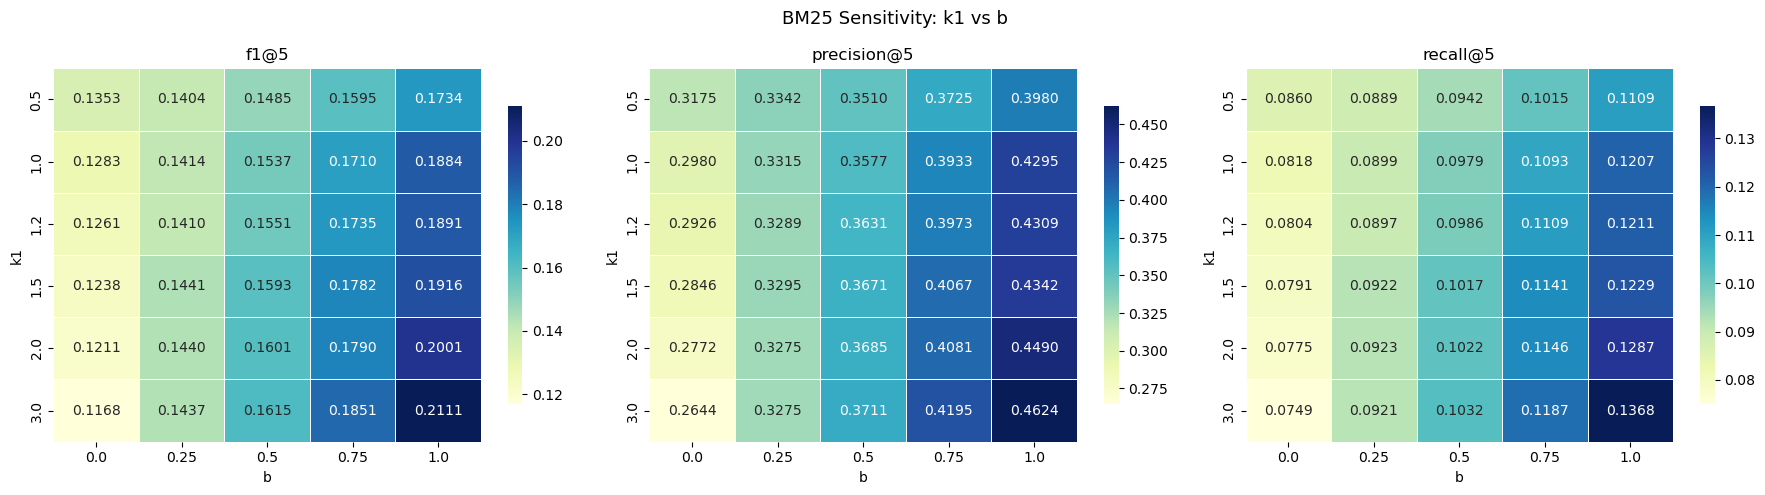

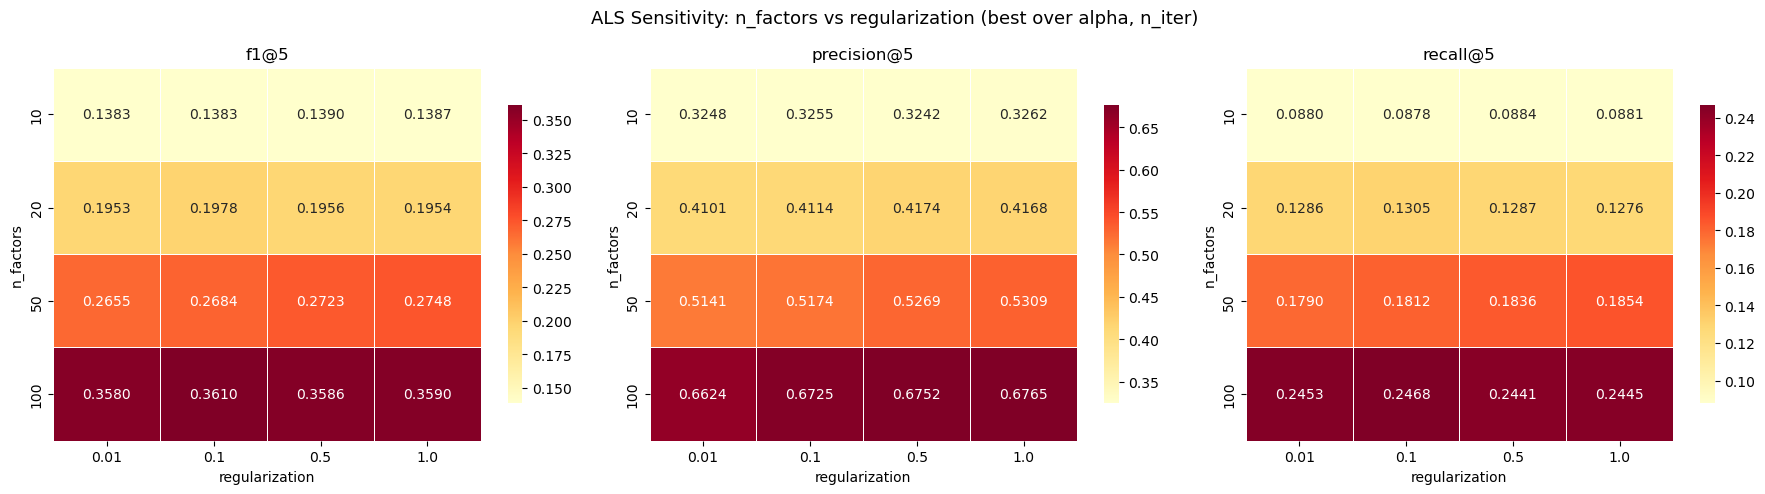

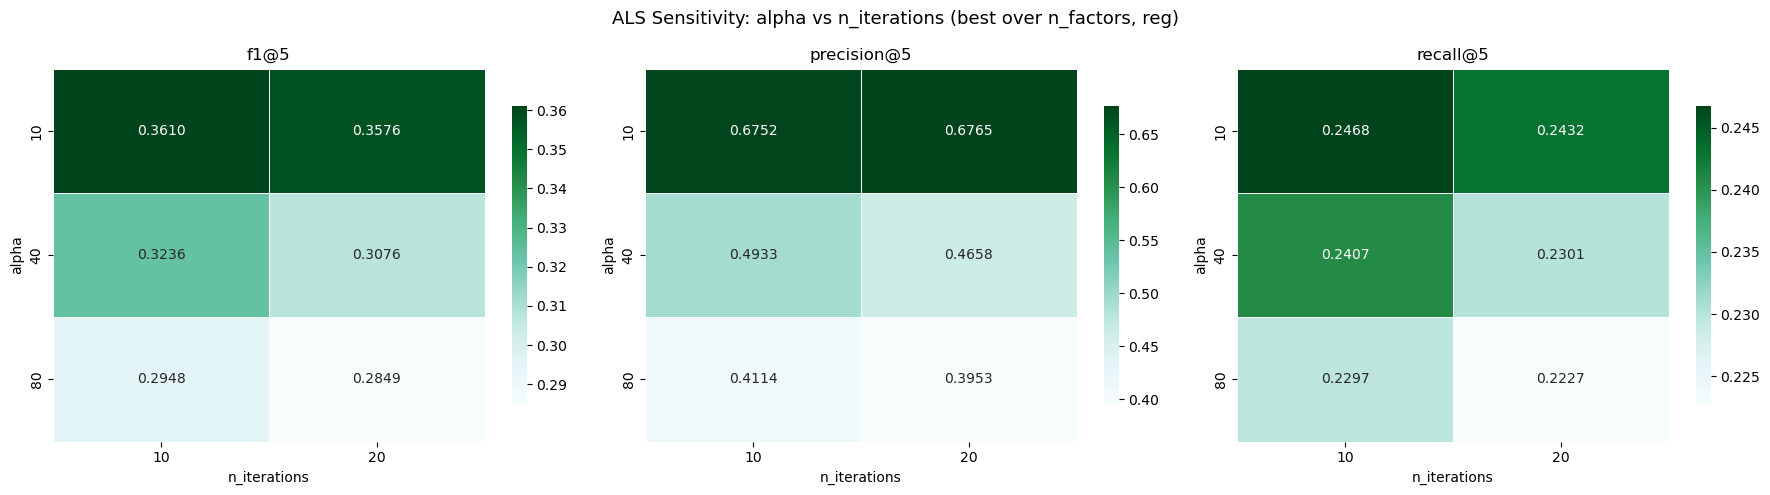

Sensitivity heatmaps saved.


In [20]:
# ══════════════════════════════════════════════════════════════════════════
#  SNIPPET T4 — Sensitivity Heatmaps
# ══════════════════════════════════════════════════════════════════════════

# BM25: k1 vs b
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("BM25 Sensitivity: k1 vs b", fontsize=13)
for ax, metric in zip(axes, ["f1@5", "precision@5", "recall@5"]):
    pivot = bm25_df.pivot_table(index="k1", columns="b", values=metric, aggfunc="max")
    sns.heatmap(pivot, annot=True, fmt=".4f", cmap="YlGnBu",
                linewidths=0.5, ax=ax, cbar_kws={"shrink": 0.8})
    ax.set_title(metric); ax.set_xlabel("b"); ax.set_ylabel("k1")
plt.tight_layout()
plt.savefig("bm25_sensitivity.png", dpi=150, bbox_inches="tight")
plt.show()

# ALS: n_factors vs regularization
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("ALS Sensitivity: n_factors vs regularization (best over alpha, n_iter)", fontsize=13)
for ax, metric in zip(axes, ["f1@5", "precision@5", "recall@5"]):
    pivot = als_df.pivot_table(index="n_factors", columns="regularization",
                               values=metric, aggfunc="max")
    sns.heatmap(pivot, annot=True, fmt=".4f", cmap="YlOrRd",
                linewidths=0.5, ax=ax, cbar_kws={"shrink": 0.8})
    ax.set_title(metric); ax.set_xlabel("regularization"); ax.set_ylabel("n_factors")
plt.tight_layout()
plt.savefig("als_sensitivity_factors_reg.png", dpi=150, bbox_inches="tight")
plt.show()

# ALS: alpha vs n_iterations
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("ALS Sensitivity: alpha vs n_iterations (best over n_factors, reg)", fontsize=13)
for ax, metric in zip(axes, ["f1@5", "precision@5", "recall@5"]):
    pivot = als_df.pivot_table(index="alpha", columns="n_iterations",
                               values=metric, aggfunc="max")
    sns.heatmap(pivot, annot=True, fmt=".4f", cmap="BuGn",
                linewidths=0.5, ax=ax, cbar_kws={"shrink": 0.8})
    ax.set_title(metric); ax.set_xlabel("n_iterations"); ax.set_ylabel("alpha")
plt.tight_layout()
plt.savefig("als_sensitivity_alpha_nit.png", dpi=150, bbox_inches="tight")
plt.show()
print("Sensitivity heatmaps saved.")


=== Best ALS params ===
n_factors         100.00000
regularization      0.10000
alpha              10.00000
n_iterations       10.00000
f1@5                0.36105
=== Best BM25 params ===
k1      3.00000
b       1.00000
f1@5    0.21112
  ALS iteration 1/10 done
  ALS iteration 2/10 done
  ALS iteration 3/10 done
  ALS iteration 4/10 done
  ALS iteration 5/10 done
  ALS iteration 6/10 done
  ALS iteration 7/10 done
  ALS iteration 8/10 done
  ALS iteration 9/10 done
  ALS iteration 10/10 done
ALS fitted: 100 factors, 10 iterations
BM25 fitted: item-item matrix (3665, 3665), k1=3.0, b=1.0
  ALS iteration 1/10 done
  ALS iteration 2/10 done
  ALS iteration 3/10 done
  ALS iteration 4/10 done
  ALS iteration 5/10 done
  ALS iteration 6/10 done
  ALS iteration 7/10 done
  ALS iteration 8/10 done
  ALS iteration 9/10 done
  ALS iteration 10/10 done
ALS fitted: 20 factors, 10 iterations
BM25 fitted: item-item matrix (3665, 3665), k1=1.5, b=0.75
=== Default vs Tuned ===
                precis

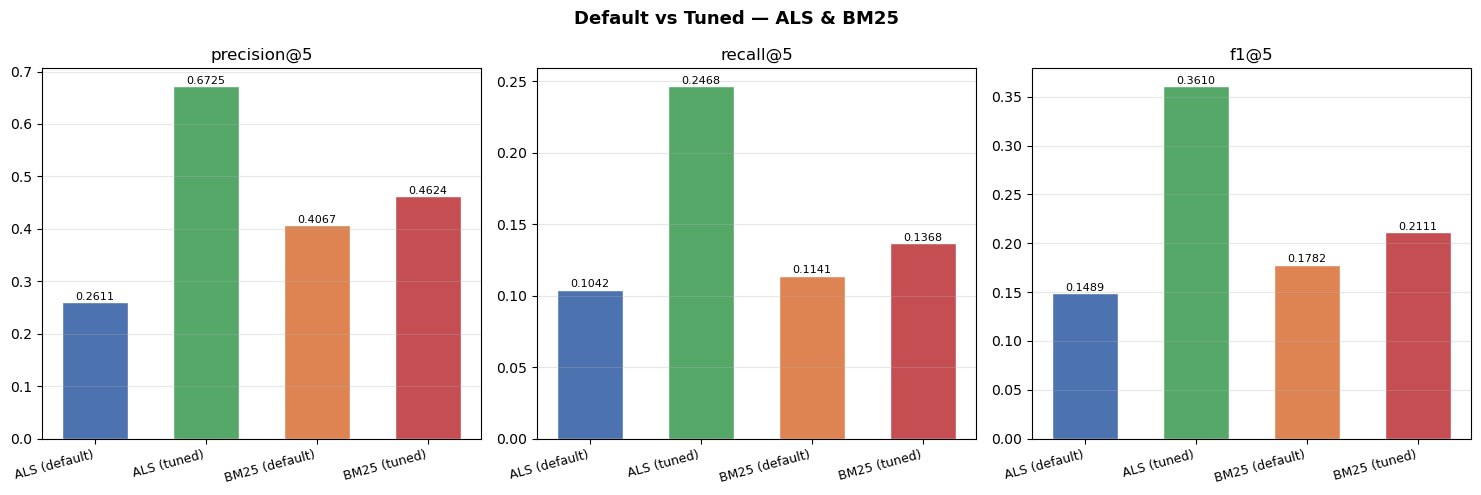

Saved als_tuning_results.csv and bm25_tuning_results.csv
Updated recommender_models\models.pkl with tuned ALS + BM25.


In [22]:
# ══════════════════════════════════════════════════════════════════════════
#  SNIPPET T5 — Re-fit tuned models, compare vs defaults, patch bundle
# ══════════════════════════════════════════════════════════════════════════
import os, pickle

# --- Re-fit best ALS ---
best_als_row  = als_df.iloc[0]
best_bm25_row = bm25_df.iloc[0]

print("=== Best ALS params ===")
print(best_als_row[["n_factors","regularization","alpha","n_iterations","f1@5"]].to_string())
print("=== Best BM25 params ===")
print(best_bm25_row[["k1","b","f1@5"]].to_string())

tuned_als  = ALSWrapper(n_factors=int(best_als_row["n_factors"]),
                        n_iterations=int(best_als_row["n_iterations"]),
                        regularization=float(best_als_row["regularization"]),
                        alpha=float(best_als_row["alpha"])).fit(user_item_matrix)
tuned_bm25 = BM25Wrapper(k1=float(best_bm25_row["k1"]),
                          b=float(best_bm25_row["b"])).fit(user_item_matrix)

# Expose inner models for downstream use (e.g. ALSCommunityRecommender)
als_rec  = tuned_als._model    # replaces the als_rec from Snippet 13
bm25_rec = tuned_bm25._model   # replaces the bm25_rec from Snippet 13

# --- Compare default vs tuned ---
default_als  = ALSWrapper(n_factors=20, n_iterations=10,
                           regularization=0.1, alpha=40).fit(user_item_matrix)
default_bm25 = BM25Wrapper(k1=1.5, b=0.75).fit(user_item_matrix)

comparison = pd.DataFrame([
    {"Model": "ALS (default)",  **evaluate_model(default_als,  user_item_matrix, n_users=300)},
    {"Model": "ALS (tuned)",    **evaluate_model(tuned_als,    user_item_matrix, n_users=300)},
    {"Model": "BM25 (default)", **evaluate_model(default_bm25, user_item_matrix, n_users=300)},
    {"Model": "BM25 (tuned)",   **evaluate_model(tuned_bm25,  user_item_matrix, n_users=300)},
]).set_index("Model")

print("=== Default vs Tuned ===")
print(comparison.to_string())

for model_name in ["ALS", "BM25"]:
    d = comparison.loc[f"{model_name} (default)", "f1@5"]
    t = comparison.loc[f"{model_name} (tuned)",   "f1@5"]
    delta = t - d
    pct   = delta / max(d, 1e-9) * 100
    print(f"{model_name} F1@5 improvement: {delta:+.5f} ({pct:+.1f}%)")

# Bar chart
labels  = comparison.index.tolist()
metrics_plot = ["precision@5", "recall@5", "f1@5"]
colors  = ["#4C72B0", "#55A868", "#DD8452", "#C44E52"]
x = np.arange(len(labels))
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle("Default vs Tuned — ALS & BM25", fontsize=13, fontweight="bold")
for ax, metric in zip(axes, metrics_plot):
    vals = comparison[metric].values
    bars = ax.bar(x, vals, color=colors, width=0.6, edgecolor="white")
    ax.set_xticks(x); ax.set_xticklabels(labels, rotation=15, ha="right", fontsize=9)
    ax.set_title(metric); ax.grid(axis="y", alpha=0.3)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.0003,
                f"{v:.4f}", ha="center", va="bottom", fontsize=8)
plt.tight_layout()
plt.savefig("als_bm25_tuning_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

# Save CSVs
als_df.to_csv("als_tuning_results.csv", index=False)
bm25_df.to_csv("bm25_tuning_results.csv", index=False)
print("Saved als_tuning_results.csv and bm25_tuning_results.csv")

# Patch model bundle if it exists
bundle_path = os.path.join("recommender_models", "models.pkl")
if os.path.exists(bundle_path):
    with open(bundle_path, "rb") as f:
        bundle = pickle.load(f)
    bundle["als"]  = als_rec
    bundle["bm25"] = bm25_rec
    bundle["als_best_params"]  = best_als_row[["n_factors","regularization","alpha","n_iterations"]].to_dict()
    bundle["bm25_best_params"] = best_bm25_row[["k1","b"]].to_dict()
    with open(bundle_path, "wb") as f:
        pickle.dump(bundle, f, protocol=4)
    print(f"Updated {bundle_path} with tuned ALS + BM25.")
else:
    print("Bundle not found — run Snippet 18 first to create it.")


In [23]:
# Snippet 14: Community-enhanced SVD, ALS, and BM25 Recommenders
# Idea: use a community partition to *restrict* the candidate set before scoring.
# For SVD/ALS (user-side): only consider items bought by same-community users.
# For BM25/ALS/SVD (item-side): only consider items in the same community as seed items.
# This acts as a diversity-and-relevance filter: latent scores are still used for ranking,
# but the search space is narrowed to topically coherent neighbourhoods.

class SVDCommunityRecommender:
    """
    SVD latent-factor recommender filtered by community membership.

    Strategy:
      - Build a community partition over the USER graph (user-based mode)
        or ITEM graph (item-based mode).
      - At inference time restrict candidates to the community of the target
        user/item, then rank by SVD dot-product score.
    """
    def __init__(self, svd_recommender, user_partition, item_partition):
        self.svd = svd_recommender
        self.user_partition = user_partition   # {user_idx: community_id}
        self.item_partition = item_partition   # {item_idx: community_id}
        # Reverse maps
        self._user_comm_members = defaultdict(list)
        for idx, c in user_partition.items():
            self._user_comm_members[c].append(idx)
        self._item_comm_members = defaultdict(list)
        for idx, c in item_partition.items():
            self._item_comm_members[c].append(idx)

    def recommend(self, user_idx, user_item_matrix, top_n=10):
        """Score unseen items; restrict to items whose community overlaps with
        items already bought by the target user's same-community peers."""
        if self.svd.user_factors is None:
            raise RuntimeError('Fit SVD first.')

        # Full SVD scores for all items
        all_scores = self.svd.user_factors[user_idx].dot(self.svd.item_factors.T)
        already_bought = set(user_item_matrix[user_idx].nonzero()[1])

        # Gather candidate items from community peers
        if user_idx in self.user_partition:
            comm = self.user_partition[user_idx]
            peer_items = set()
            for peer in self._user_comm_members[comm]:
                if peer == user_idx:
                    continue
                peer_items.update(user_item_matrix[peer].nonzero()[1])
            candidates = peer_items - already_bought
        else:
            candidates = set(range(len(all_scores))) - already_bought

        if not candidates:
            # Fall back to global SVD ranking
            candidates = set(range(len(all_scores))) - already_bought

        candidate_list = list(candidates)
        candidate_scores = all_scores[candidate_list]
        order = np.argsort(candidate_scores)[::-1][:top_n]
        return [(candidate_list[i], float(candidate_scores[i])) for i in order]


class ALSCommunityRecommender:
    """
    ALS latent-factor recommender filtered by community membership.
    Identical structure to SVDCommunityRecommender — swaps SVD factors for ALS.
    """
    def __init__(self, als_recommender, user_partition, item_partition):
        self.als = als_recommender
        self.user_partition = user_partition
        self.item_partition = item_partition
        self._user_comm_members = defaultdict(list)
        for idx, c in user_partition.items():
            self._user_comm_members[c].append(idx)
        self._item_comm_members = defaultdict(list)
        for idx, c in item_partition.items():
            self._item_comm_members[c].append(idx)

    def recommend(self, user_idx, user_item_matrix, top_n=10):
        if self.als.user_factors is None:
            raise RuntimeError('Fit ALS first.')

        all_scores = self.als.user_factors[user_idx].dot(self.als.item_factors.T)
        already_bought = set(user_item_matrix[user_idx].nonzero()[1])

        if user_idx in self.user_partition:
            comm = self.user_partition[user_idx]
            peer_items = set()
            for peer in self._user_comm_members[comm]:
                if peer == user_idx:
                    continue
                peer_items.update(user_item_matrix[peer].nonzero()[1])
            candidates = peer_items - already_bought
        else:
            candidates = set(range(len(all_scores))) - already_bought

        if not candidates:
            candidates = set(range(len(all_scores))) - already_bought

        candidate_list = list(candidates)
        candidate_scores = all_scores[candidate_list]
        order = np.argsort(candidate_scores)[::-1][:top_n]
        return [(candidate_list[i], float(candidate_scores[i])) for i in order]


class BM25CommunityRecommender:
    """
    BM25 item-item recommender filtered by community membership.

    Strategy: aggregate BM25 scores only over items that share a community
    with at least one seed item bought by the target user.
    """
    def __init__(self, bm25_recommender, item_partition):
        self.bm25 = bm25_recommender
        self.item_partition = item_partition
        self._item_comm_members = defaultdict(list)
        for idx, c in item_partition.items():
            self._item_comm_members[c].append(idx)

    def recommend(self, user_idx, user_item_matrix, top_n=10):
        seed_items = list(user_item_matrix[user_idx].nonzero()[1])
        if not seed_items or self.bm25.item_scores is None:
            return []

        # Collect community-constrained candidates
        community_candidates = set()
        for seed in seed_items:
            if seed in self.item_partition:
                comm = self.item_partition[seed]
                community_candidates.update(self._item_comm_members[comm])
        community_candidates -= set(seed_items)

        if not community_candidates:
            community_candidates = set(range(self.bm25.item_scores.shape[1])) - set(seed_items)

        # Score candidates using BM25 item-item matrix
        scores = np.zeros(self.bm25.item_scores.shape[1], dtype=np.float32)
        for item_idx in seed_items:
            rating = user_item_matrix[user_idx, item_idx]
            scores += rating * self.bm25.item_scores[item_idx]

        # Restrict to community candidates
        candidate_list = list(community_candidates)
        candidate_scores = scores[candidate_list]
        order = np.argsort(candidate_scores)[::-1][:top_n]
        return [(candidate_list[i], float(candidate_scores[i])) for i in order]


def evaluate_hybrid(recommender, user_item_matrix, k_values=[5, 10],
                    n_users=200, random_state=42):
    """Generic leave-some-out evaluator for any recommender with a .recommend() method."""
    rng = np.random.RandomState(random_state)
    results = {k: {'precision': [], 'recall': []} for k in k_values}

    for user_idx in range(min(n_users, user_item_matrix.shape[0])):
        user_items = list(user_item_matrix[user_idx].nonzero()[1])
        if len(user_items) < 3:
            continue
        n_train = max(1, len(user_items) // 2)
        idx_perm = rng.permutation(len(user_items))
        train_items = set(np.array(user_items)[idx_perm[:n_train]])
        test_items  = set(np.array(user_items)[idx_perm[n_train:]])
        if not test_items:
            continue

        masked = user_item_matrix.tolil()
        for item_idx in test_items:
            masked[user_idx, item_idx] = 0
        masked = masked.tocsr()

        for k in k_values:
            recs = recommender.recommend(user_idx, masked, top_n=k)
            recommended = set(idx for idx, _ in recs)
            hits = len(recommended & test_items)
            results[k]['precision'].append(hits / len(recommended) if recommended else 0)
            results[k]['recall'].append(hits / len(test_items))

    out = {}
    for k in k_values:
        p = np.mean(results[k]['precision']) if results[k]['precision'] else 0
        r = np.mean(results[k]['recall'])    if results[k]['recall']    else 0
        f = 2*p*r/(p+r) if (p+r) > 0 else 0
        out[f'precision@{k}'] = p
        out[f'recall@{k}']    = r
        out[f'f1@{k}']        = f
    return out


print('Community-enhanced SVD / ALS / BM25 classes defined.')
print('evaluate_hybrid() defined — same leave-some-out protocol as all other methods.')


Community-enhanced SVD / ALS / BM25 classes defined.
evaluate_hybrid() defined — same leave-some-out protocol as all other methods.


In [24]:
# Snippet 15: Run community-enhanced SVD, ALS, BM25 over all four community algorithms
# For each community algorithm we build:
#   - SVD + community filter (user graph partition)
#   - ALS + community filter (user graph partition)
#   - BM25 + community filter (item graph partition)

import warnings
warnings.filterwarnings('ignore')

# Re-use pre-computed SVD, ALS, BM25 models and user/item graphs from earlier cells.
# We re-run community detection to get fresh partition dicts per algorithm.

hybrid_results = {}   # key = 'SVD+Louvain', 'ALS+Leiden', 'BM25+Infomap', ...

for algo_name, algo_func in algo_funcs.items():
    print(f'\n=== Community algorithm: {algo_name} ===')

    # --- Partitions ---
    u_partition, u_mod = algo_func(user_graph)
    i_partition, i_mod = algo_func(item_graph)
    print(f'  User communities: {len(set(u_partition.values()))}  '
          f'| Item communities: {len(set(i_partition.values()))}  '
          f'| User modularity: {u_mod:.4f}  | Item modularity: {i_mod:.4f}')

    # --- SVD + community ---
    svd_comm = SVDCommunityRecommender(svd_rec, u_partition, i_partition)
    svd_comm_metrics = evaluate_hybrid(svd_comm, user_item_matrix, k_values=[5, 10])
    key = f'SVD+{algo_name}'
    hybrid_results[key] = svd_comm_metrics
    print(f'  {key}  P@5={svd_comm_metrics["precision@5"]:.4f}  '
          f'R@5={svd_comm_metrics["recall@5"]:.4f}  '
          f'F1@5={svd_comm_metrics["f1@5"]:.4f}')

    # --- ALS + community ---
    als_comm = ALSCommunityRecommender(als_rec, u_partition, i_partition)
    als_comm_metrics = evaluate_hybrid(als_comm, user_item_matrix, k_values=[5, 10])
    key = f'ALS+{algo_name}'
    hybrid_results[key] = als_comm_metrics
    print(f'  {key}  P@5={als_comm_metrics["precision@5"]:.4f}  '
          f'R@5={als_comm_metrics["recall@5"]:.4f}  '
          f'F1@5={als_comm_metrics["f1@5"]:.4f}')

    # --- BM25 + community ---
    bm25_comm = BM25CommunityRecommender(bm25_rec, i_partition)
    bm25_comm_metrics = evaluate_hybrid(bm25_comm, user_item_matrix, k_values=[5, 10])
    key = f'BM25+{algo_name}'
    hybrid_results[key] = bm25_comm_metrics
    print(f'  {key}  P@5={bm25_comm_metrics["precision@5"]:.4f}  '
          f'R@5={bm25_comm_metrics["recall@5"]:.4f}  '
          f'F1@5={bm25_comm_metrics["f1@5"]:.4f}')

print('\nAll hybrid evaluations complete.')



=== Community algorithm: Louvain ===
  User communities: 11  | Item communities: 17  | User modularity: 0.2825  | Item modularity: 0.3444
  SVD+Louvain  P@5=0.6302  R@5=0.1776  F1@5=0.2771
  ALS+Louvain  P@5=0.6754  R@5=0.2556  F1@5=0.3709
  BM25+Louvain  P@5=0.4643  R@5=0.1424  F1@5=0.2180

=== Community algorithm: Leiden ===
  User communities: 11  | Item communities: 17  | User modularity: 0.2832  | Item modularity: 0.3515
  SVD+Leiden  P@5=0.6302  R@5=0.1776  F1@5=0.2771
  ALS+Leiden  P@5=0.6754  R@5=0.2556  F1@5=0.3709
  BM25+Leiden  P@5=0.4643  R@5=0.1424  F1@5=0.2180

=== Community algorithm: Infomap ===
  User communities: 18  | Item communities: 32  | User modularity: 0.1180  | Item modularity: 0.2426
  SVD+Infomap  P@5=0.6231  R@5=0.1709  F1@5=0.2683
  ALS+Infomap  P@5=0.6482  R@5=0.2258  F1@5=0.3350
  BM25+Infomap  P@5=0.4633  R@5=0.1414  F1@5=0.2167

=== Community algorithm: FluidC ===
  User communities: 54  | Item communities: 60  | User modularity: 0.1915  | Item modula

=== Full Comparison: Community Baselines vs Community-Enhanced Hybrids ===
                        Precision@5  Recall@5    F1@5  Precision@10  Recall@10   F1@10
Method                                                                                
Community-UU (Louvain)       0.4543    0.1582  0.2347        0.3467     0.2184  0.2680
Community-II (Infomap)       0.4613    0.1204  0.1910        0.3648     0.1768  0.2382
SVD+Louvain                  0.6302    0.1776  0.2771        0.5005     0.2561  0.3388
ALS+Louvain                  0.6754    0.2556  0.3709        0.6050     0.3947  0.4777
BM25+Louvain                 0.4643    0.1424  0.2180        0.3482     0.1992  0.2534
SVD+Leiden                   0.6302    0.1776  0.2771        0.5005     0.2561  0.3388
ALS+Leiden                   0.6754    0.2556  0.3709        0.6050     0.3947  0.4777
BM25+Leiden                  0.4643    0.1424  0.2180        0.3492     0.2015  0.2555
SVD+Infomap                  0.6231    0.1709  0.2683  

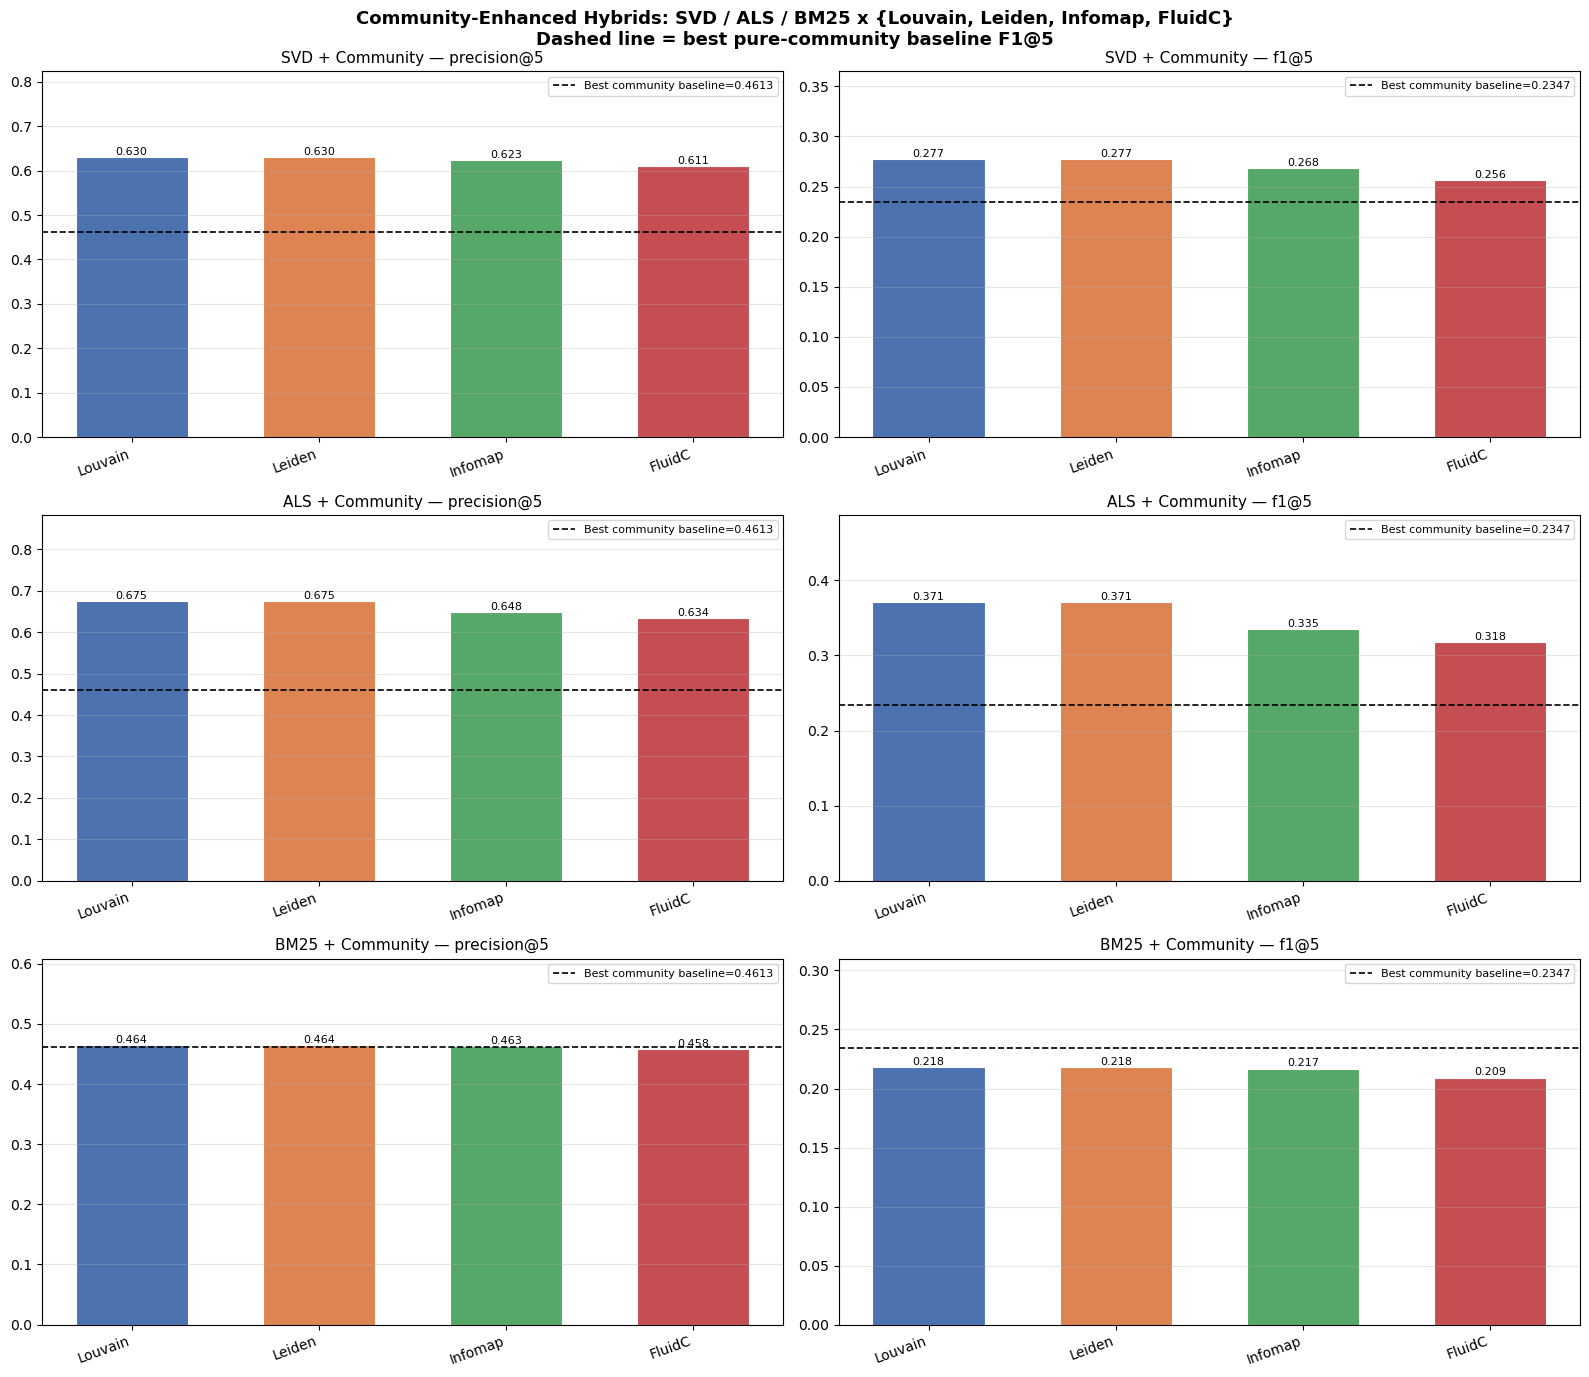


=== Winner Summary by F1@5 ===
Overall best: ALS+Louvain  (F1@5 = 0.3709)
  SVD: best hybrid = Louvain  F1@5=0.2771  (vs best community baseline=0.2347, delta=+0.0424)
  ALS: best hybrid = Louvain  F1@5=0.3709  (vs best community baseline=0.2347, delta=+0.1362)
  BM25: best hybrid = Louvain  F1@5=0.2180  (vs best community baseline=0.2347, delta=-0.0167)


In [25]:
# Snippet 16: Full comparison — Community (Jaccard) vs Community-Enhanced SVD / ALS / BM25

import warnings
warnings.filterwarnings('ignore')

# ------------------------------------------------------------------
# 1. Full metrics table
# ------------------------------------------------------------------
best_comm_name_u = max(user_results, key=lambda k: user_results[k].get('f1@5', 0))
best_comm_name_i = max(item_results, key=lambda k: item_results[k].get('f1@5', 0))

baseline_methods = {
    f'Community-UU ({best_comm_name_u})': max(user_results.values(), key=lambda x: x.get('f1@5', 0)),
    f'Community-II ({best_comm_name_i})': max(item_results.values(), key=lambda x: x.get('f1@5', 0)),
}

all_extended = {**baseline_methods, **hybrid_results}

rows = []
for name, m in all_extended.items():
    rows.append({
        'Method':       name,
        'Precision@5':  round(m.get('precision@5',  0), 4),
        'Recall@5':     round(m.get('recall@5',     0), 4),
        'F1@5':         round(m.get('f1@5',         0), 4),
        'Precision@10': round(m.get('precision@10', 0), 4),
        'Recall@10':    round(m.get('recall@10',    0), 4),
        'F1@10':        round(m.get('f1@10',        0), 4),
    })

df_ext = pd.DataFrame(rows).set_index('Method')
print('=== Full Comparison: Community Baselines vs Community-Enhanced Hybrids ===')
print(df_ext.to_string())

# ------------------------------------------------------------------
# 2. Group bar chart: community algos x hybrid model
# ------------------------------------------------------------------
algo_list = list(algo_funcs.keys())   # Louvain, Leiden, Infomap, FluidC

svd_hybrids  = {a: hybrid_results[f'SVD+{a}']  for a in algo_list}
als_hybrids  = {a: hybrid_results[f'ALS+{a}']  for a in algo_list}
bm25_hybrids = {a: hybrid_results[f'BM25+{a}'] for a in algo_list}

fig, axes = plt.subplots(3, 2, figsize=(16, 14))
fig.suptitle(
    'Community-Enhanced Hybrids: SVD / ALS / BM25 x {Louvain, Leiden, Infomap, FluidC}\n'
    'Dashed line = best pure-community baseline F1@5',
    fontsize=13, fontweight='bold'
)

palette4 = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']
x4 = np.arange(len(algo_list))
width4 = 0.6
best_baseline_f1 = max(v.get('f1@5', 0) for v in baseline_methods.values())
best_baseline_p5 = max(v.get('precision@5', 0) for v in baseline_methods.values())

plot_configs = [
    (axes[0, 0], svd_hybrids,  'SVD + Community',  'precision@5', best_baseline_p5),
    (axes[0, 1], svd_hybrids,  'SVD + Community',  'f1@5',        best_baseline_f1),
    (axes[1, 0], als_hybrids,  'ALS + Community',  'precision@5', best_baseline_p5),
    (axes[1, 1], als_hybrids,  'ALS + Community',  'f1@5',        best_baseline_f1),
    (axes[2, 0], bm25_hybrids, 'BM25 + Community', 'precision@5', best_baseline_p5),
    (axes[2, 1], bm25_hybrids, 'BM25 + Community', 'f1@5',        best_baseline_f1),
]

for ax, hybrids, label, metric, baseline_val in plot_configs:
    values = [hybrids[a].get(metric, 0) for a in algo_list]
    bars = ax.bar(x4, values, width4, color=palette4, edgecolor='white', linewidth=0.8)
    ax.axhline(baseline_val, color='black', linestyle='--', linewidth=1.2,
               label=f'Best community baseline={baseline_val:.4f}')
    ax.set_title(f'{label} — {metric}', fontsize=11)
    ax.set_xticks(x4)
    ax.set_xticklabels(algo_list, rotation=20, ha='right')
    ax.set_ylim(0, max(max(values), baseline_val) * 1.3 + 0.005)
    ax.grid(axis='y', alpha=0.3)
    ax.legend(fontsize=8)
    for bar, val in zip(bars, values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.0005,
                f'{val:.3f}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.savefig('hybrid_community_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# ------------------------------------------------------------------
# 3. Winner summary
# ------------------------------------------------------------------
print('\n=== Winner Summary by F1@5 ===')
best_overall = max(all_extended, key=lambda k: all_extended[k].get('f1@5', 0))
print(f'Overall best: {best_overall}  (F1@5 = {all_extended[best_overall]["f1@5"]:.4f})')

for base, hybrids in [('SVD', svd_hybrids), ('ALS', als_hybrids), ('BM25', bm25_hybrids)]:
    best_h = max(hybrids, key=lambda k: hybrids[k].get('f1@5', 0))
    hybrid_f1 = hybrids[best_h]['f1@5']
    delta = hybrid_f1 - best_baseline_f1
    sign = '+' if delta >= 0 else ''
    print(f'  {base}: best hybrid = {best_h}  '
          f'F1@5={hybrid_f1:.4f}  (vs best community baseline={best_baseline_f1:.4f}, delta={sign}{delta:.4f})')


In [26]:
import joblib

# Save extended results table
df_ext.to_csv('als.csv')
print('Results saved to als.csv')


Results saved to als.csv


In [ ]:
# # ══════════════════════════════════════════════════════════════
# #  SAVE ALL MODELS FOR STREAMLIT APP (incl. SVD, ALS, BM25)
# # ══════════════════════════════════════════════════════════════
# import os, pickle
# import pandas as pd

# MODEL_DIR = "recommender_models"
# os.makedirs(MODEL_DIR, exist_ok=True)

# # ── 1. Community detection for all 4 algorithms ──
# algo_funcs_save = {
#     "Louvain": detect_communities_louvain,
#     "Leiden":  detect_communities_leiden,
#     "Infomap": detect_communities_infomap,
#     "FluidC":  lambda G: detect_communities_fluidc(G, n_communities=50),
# }

# user_partitions = {}
# item_partitions = {}
# metrics = {"user": {}, "item": {}, "hybrid": {}}

# for algo_name, algo_func in algo_funcs_save.items():
#     u_part, u_mod = algo_func(user_graph)
#     i_part, i_mod = algo_func(item_graph)

#     user_partitions[algo_name] = u_part
#     item_partitions[algo_name] = i_part

#     metrics["user"][algo_name] = {
#         "modularity":    u_mod,
#         "n_communities": len(set(u_part.values())),
#         **user_results.get(algo_name, {}),
#     }
#     metrics["item"][algo_name] = {
#         "modularity":    i_mod,
#         "n_communities": len(set(i_part.values())),
#         **item_results.get(algo_name, {}),
#     }
#     # Hybrid metrics per algo (SVD / ALS / BM25 + community)
#     for prefix in ("SVD", "ALS", "BM25"):
#         key = f"{prefix}+{algo_name}"
#         if key in hybrid_results:
#             metrics["hybrid"][key] = hybrid_results[key]

# # ── 2. idx_to_item reverse map ──
# idx_to_item = {idx: item for item, idx in item_to_idx.items()}

# # ── 3. Bundle everything ──
# model_bundle = {
#     # Core data
#     "user_item_matrix": user_item_matrix,
#     "user_similarity":  user_similarity,
#     "item_similarity":  item_similarity,
#     "users":            users,
#     "items":            items,
#     "user_to_idx":      user_to_idx,
#     "item_to_idx":      item_to_idx,
#     "idx_to_item":      idx_to_item,
#     # Community partitions
#     "user_partitions":  user_partitions,
#     "item_partitions":  item_partitions,
#     # Latent factor models
#     "svd":              svd_rec,     # SVDRecommender (fitted)
#     "als":              als_rec,     # ALSRecommender (fitted)
#     "bm25":             bm25_rec,    # BM25Recommender (fitted)
#     # Metrics
#     "metrics":          metrics,
# }

# with open(os.path.join(MODEL_DIR, "models.pkl"), "wb") as f:
#     pickle.dump(model_bundle, f, protocol=4)

# # ── 4. Product info ──
# product_info = (
#     df.dropna(subset=["StockCode", "Description", "UnitPrice"])
#       .groupby("StockCode", as_index=False)
#       .agg(Description=("Description", "first"), UnitPrice=("UnitPrice", "median"))
# )
# product_info.to_pickle(os.path.join(MODEL_DIR, "product_info.pkl"))

# print(f"✅ Saved to '{MODEL_DIR}/'")
# print(f"   models.pkl       — matrix, similarities, SVD/ALS/BM25, partitions, metrics")
# print(f"   product_info.pkl — {len(product_info)} products")